#### 🤖 Model Training for Customer Churn Prediction
#### **Goal:** Train and compare multiple classification models
#### **Models:** Logistic Regression, Random Forest, XGBoost, LightGBM
#### **Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

#### 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, confusion_matrix,
                           classification_report, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# For model interpretation
import shap
from sklearn.inspection import permutation_importance

In [3]:
# Professional settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✅ Libraries imported")

✅ Libraries imported


#### 2. Load processed data
#### Load the feature-engineered data

In [4]:
X_train = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/processed/X_train.csv')
X_test = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/processed/X_test.csv')
y_train = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/processed/y_test.csv').squeeze()
X_train_resampled = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/processed/X_train_resampled.csv')
y_train_resampled = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/processed/y_train_resampled.csv').squeeze()
feature_names = pd.read_csv('C:/Users/pc\Documents/customer-churn-enterprise/data/processed/feature_names.csv').squeeze().tolist()

print(f"✅ Data loaded successfully")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"\nFeatures: {len(feature_names)}")


✅ Data loaded successfully
X_train: (5634, 6568)
X_test: (1409, 6568)
y_train: (5634,)
y_test: (1409,)

Features: 6568


#### 3. Define evaluation function

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Comprehensive model evaluation function
    """
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    
    # Print results
    print(f"\n{'='*60}")
    print(f"📊 {model_name} PERFORMANCE")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    # Classification Report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    # Return metrics
    return {
        'model': model,
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'cm': cm
    }


#### 4. Train multiple models

#### Initialize results dictionary

In [6]:
results = {}

 #### 4.1 Logistic Regression (Baseline Model)

In [7]:
print("\n🔵 Training Logistic Regression...")
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
results['Logistic Regression'] = evaluate_model(
    log_reg, X_train, y_train, X_test, y_test, "Logistic Regression"
)


🔵 Training Logistic Regression...

📊 Logistic Regression PERFORMANCE
Accuracy:  0.7644
Precision: 0.5395
Recall:    0.7674
F1-Score:  0.6336
ROC-AUC:   0.8459
CV ROC-AUC: 0.8481 (+/- 0.0265)

📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.80      0.76      0.78      1409



#### 4.2 Random forest

In [8]:
print("\n🟢 Training Random Forest...")
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1
)
results['Random Forest'] = evaluate_model(
    rf, X_train, y_train, X_test, y_test, "Random Forest"
)


🟢 Training Random Forest...

📊 Random Forest PERFORMANCE
Accuracy:  0.6977
Precision: 0.4607
Recall:    0.8155
F1-Score:  0.5888
ROC-AUC:   0.8114
CV ROC-AUC: 0.8182 (+/- 0.0449)

📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.66      0.76      1035
       Churn       0.46      0.82      0.59       374

    accuracy                           0.70      1409
   macro avg       0.68      0.74      0.67      1409
weighted avg       0.79      0.70      0.72      1409



#### 4.3 XGBoost

In [9]:
print("\n🟠 Training XGBoost...")
xgb = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # Handle imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
results['XGBoost'] = evaluate_model(
    xgb, X_train, y_train, X_test, y_test, "XGBoost"
)


🟠 Training XGBoost...

📊 XGBoost PERFORMANCE
Accuracy:  0.7530
Precision: 0.5233
Recall:    0.7807
F1-Score:  0.6266
ROC-AUC:   0.8419
CV ROC-AUC: 0.8365 (+/- 0.0239)

📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.82      1035
       Churn       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



#### 4.4 LightGBM

In [10]:
print("\n🟣 Training LightGBM...")
lgbm = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    verbose=-1,
    n_jobs=-1
)
results['LightGBM'] = evaluate_model(
    lgbm, X_train, y_train, X_test, y_test, "LightGBM"
)


🟣 Training LightGBM...

📊 LightGBM PERFORMANCE
Accuracy:  0.7587
Precision: 0.5311
Recall:    0.7754
F1-Score:  0.6304
ROC-AUC:   0.8378
CV ROC-AUC: 0.8339 (+/- 0.0259)

📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



#### 4.5 Gradient Boosting

In [11]:
print("\n🔴 Training Gradient Boosting...")
gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8
)
results['Gradient Boosting'] = evaluate_model(
    gb, X_train, y_train, X_test, y_test, "Gradient Boosting"
)


🔴 Training Gradient Boosting...

📊 Gradient Boosting PERFORMANCE
Accuracy:  0.8020
Precision: 0.6599
Recall:    0.5241
F1-Score:  0.5842
ROC-AUC:   0.8471
CV ROC-AUC: 0.8439 (+/- 0.0268)

📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



### 5. Compare All Models

In [12]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'ROC-AUC': f"{metrics['roc_auc']:.4f}",
        'CV Score': f"{metrics['cv_mean']:.4f} (±{metrics['cv_std']*2:.4f})"
    }
    for name, metrics in results.items()
}).T

print("\n" + "="*80)
print("📊 MODEL COMPARISON SUMMARY")
print("="*80)
comparison_df


📊 MODEL COMPARISON SUMMARY


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Score
Logistic Regression,0.7644,0.5395,0.7674,0.6336,0.8459,0.8481 (±0.0265)
Random Forest,0.6977,0.4607,0.8155,0.5888,0.8114,0.8182 (±0.0449)
XGBoost,0.7530,0.5233,0.7807,0.6266,0.8419,0.8365 (±0.0239)
LightGBM,0.7587,0.5311,0.7754,0.6304,0.8378,0.8339 (±0.0259)
Gradient Boosting,0.8020,0.6599,0.5241,0.5842,0.8471,0.8439 (±0.0268)


### 6. Visualize Model Performance
#### 6.1 ROC curves
#### 6.2 Metrics Comparison Bar Plot
#### 6.3 Confusion Matrices

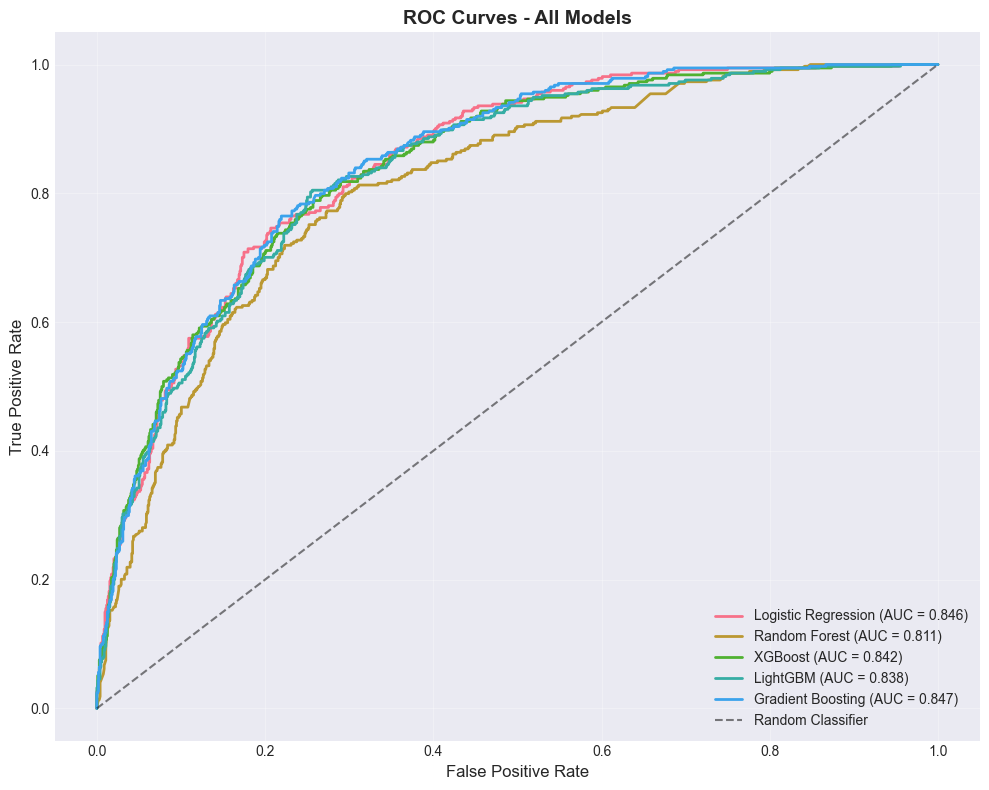

In [13]:
# 6.1 ROC Curves
plt.figure(figsize=(10, 8))
for name, metrics in results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/pc\Documents/customer-churn-enterprise/reports/figures/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

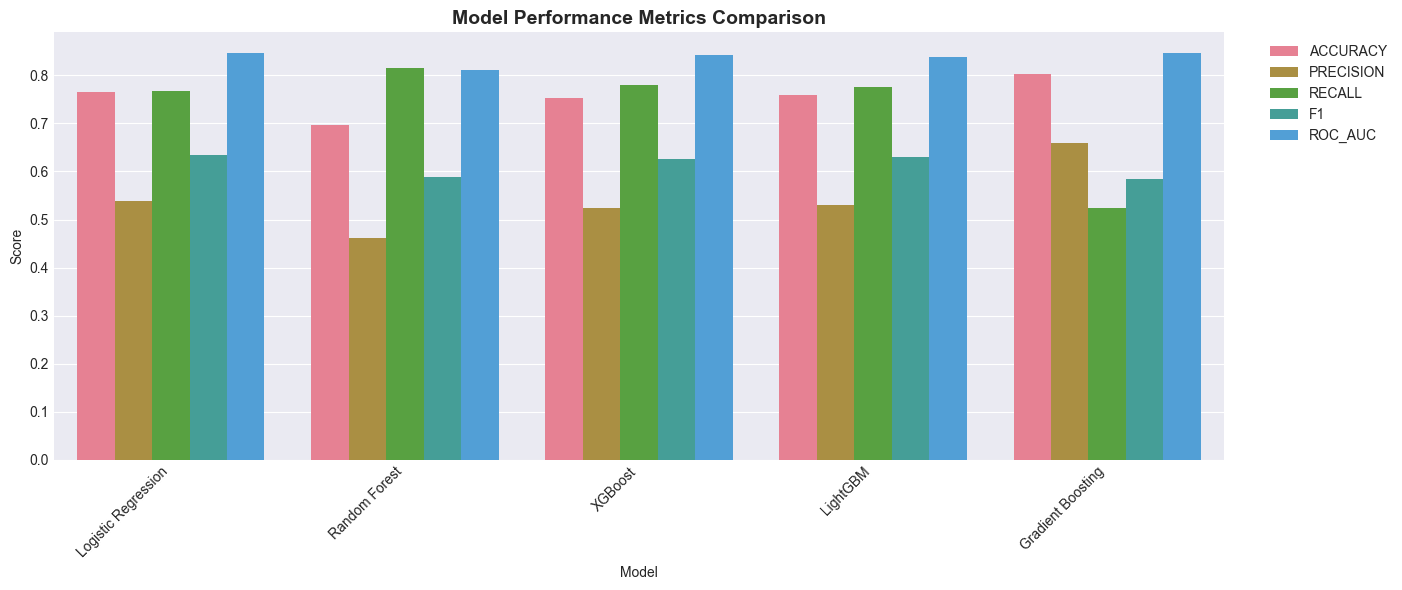

In [14]:
# 6.2 Metrics Comparison Bar Plot
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metrics_data = []
for name in results.keys():
    for metric in metrics_to_plot:
        metrics_data.append({
            'Model': name,
            'Metric': metric.upper(),
            'Score': results[name][metric]
        })

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(14, 6))
sns.barplot(data=metrics_df, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.savefig('C:/Users/pc\Documents/customer-churn-enterprise/reports/figures/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

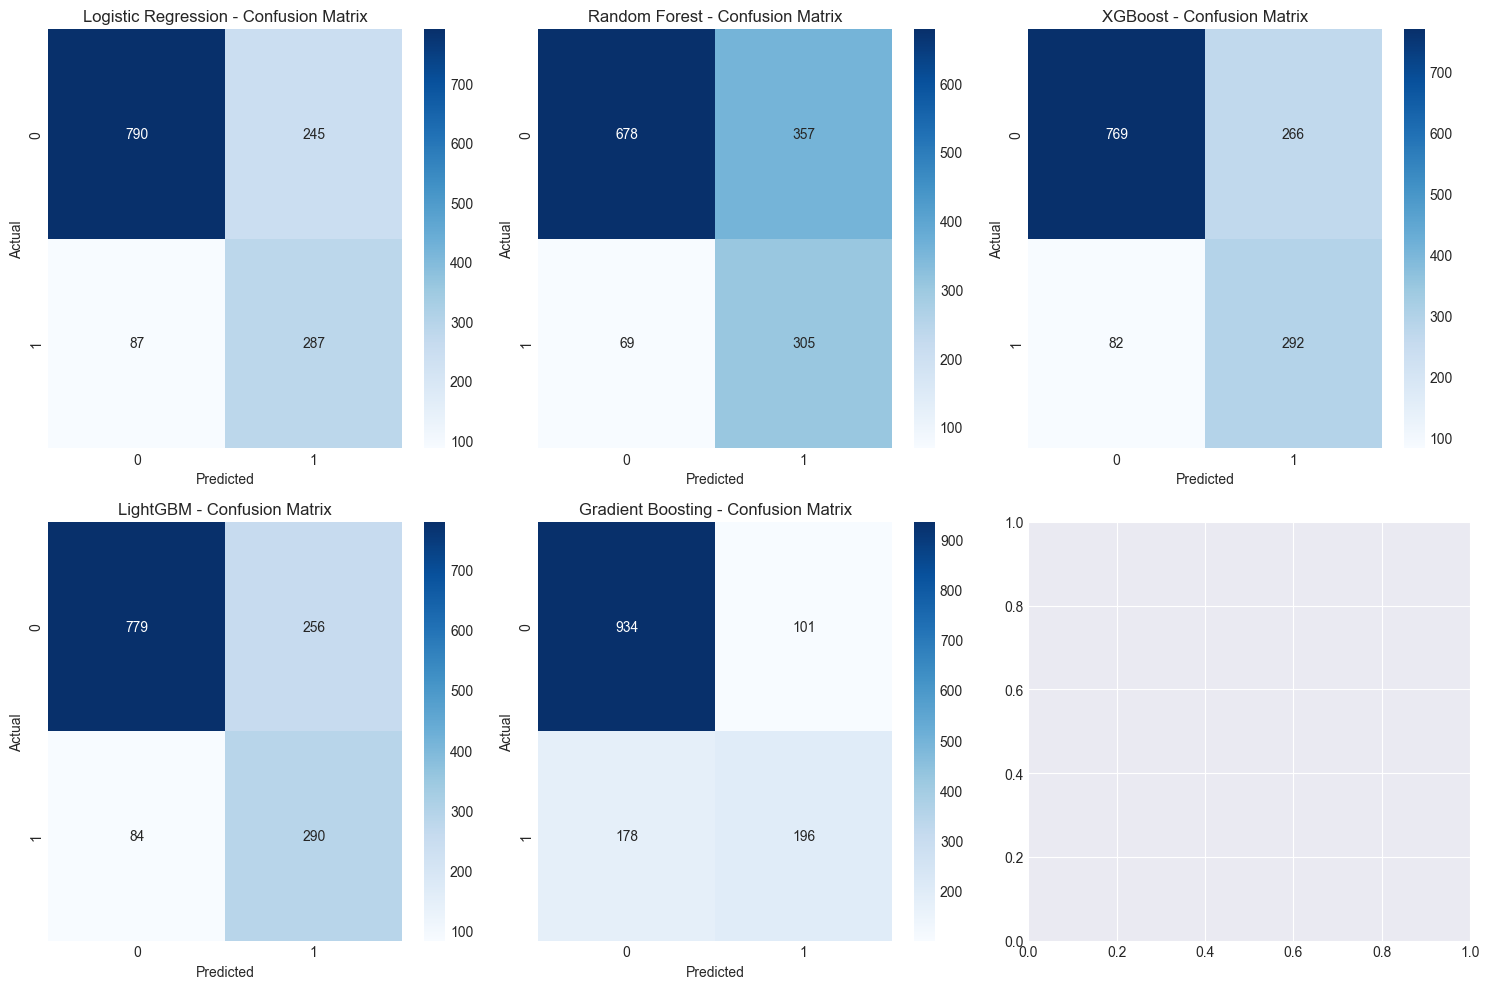

In [15]:
# 6.3 Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, metrics) in enumerate(results.items()):
    if idx < 6:  # Limit to 6 models
        sns.heatmap(metrics['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{name} - Confusion Matrix')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('C:/Users/pc\Documents/customer-churn-enterprise/reports/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

#### 7. Find Best Model
#### Select best model based on F1-score (good balance of precision and recall)

In [16]:
best_model_name = max(results.keys(), key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']

print(f"\nBEST MODEL: {best_model_name}")
print(f"F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")


BEST MODEL: Logistic Regression
F1-Score: 0.6336
ROC-AUC: 0.8459


#### 8. Hyperparameter Tuning for Best Model

In [17]:
if best_model_name == 'Random Forest':
    print("\n🔧 Tuning Random Forest hyperparameters...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [10, 20],
        'min_samples_leaf': [5, 10]
    }
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best F1-score: {grid_search.best_score_:.4f}")
    
    # Update best model
    best_model = grid_search.best_estimator_
    best_model_name = f"Tuned {best_model_name}"

#### 9. Feature Importance Analysis
#### 9.1 For tree-based models

In [18]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 20 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('../reports/figures/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 TOP 10 MOST IMPORTANT FEATURES:")
    print(feature_importance.head(10).to_string(index=False))

#### 10. SHAP Analysis (Model Interpretability)

In [19]:
print(type(best_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


📁 Saving plots to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures

🔮 Generating SHAP explanations (this may take a minute)...
✅ Saved bar chart to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_feature_importance_bar.png


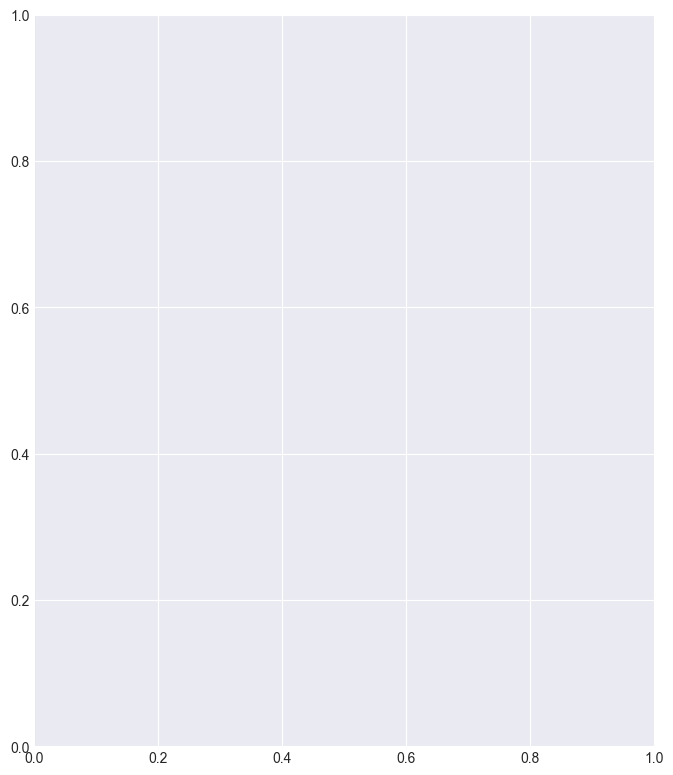

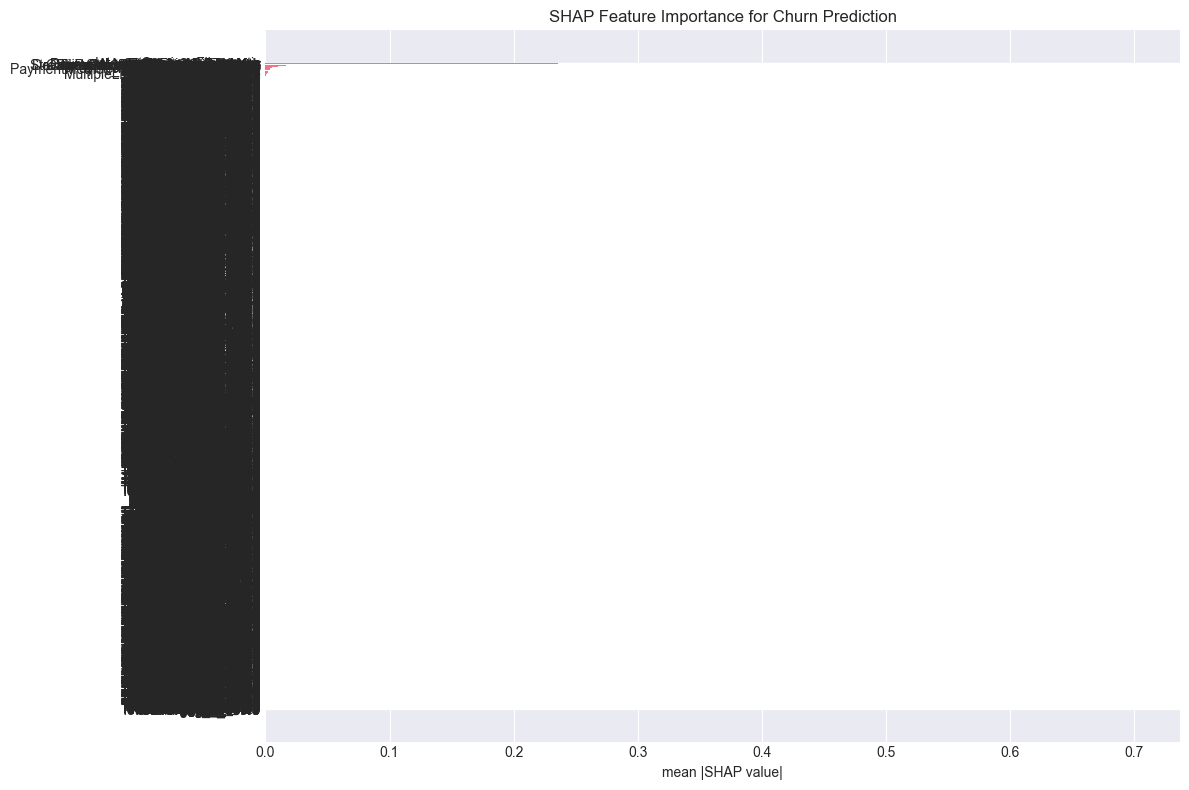


📊 Individual prediction explanations:
✅ Saved waterfall plot 1 to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_waterfall_customer_1.png


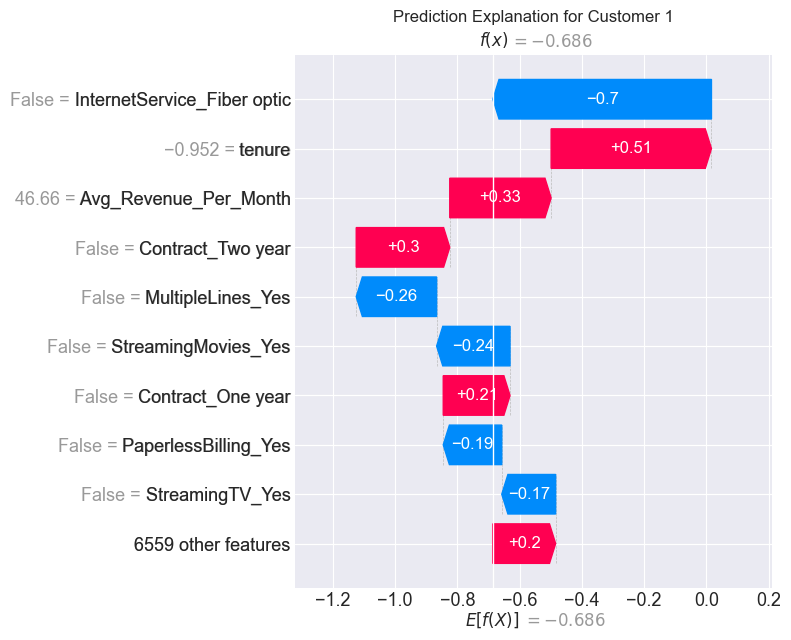

✅ Saved waterfall plot 2 to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_waterfall_customer_2.png


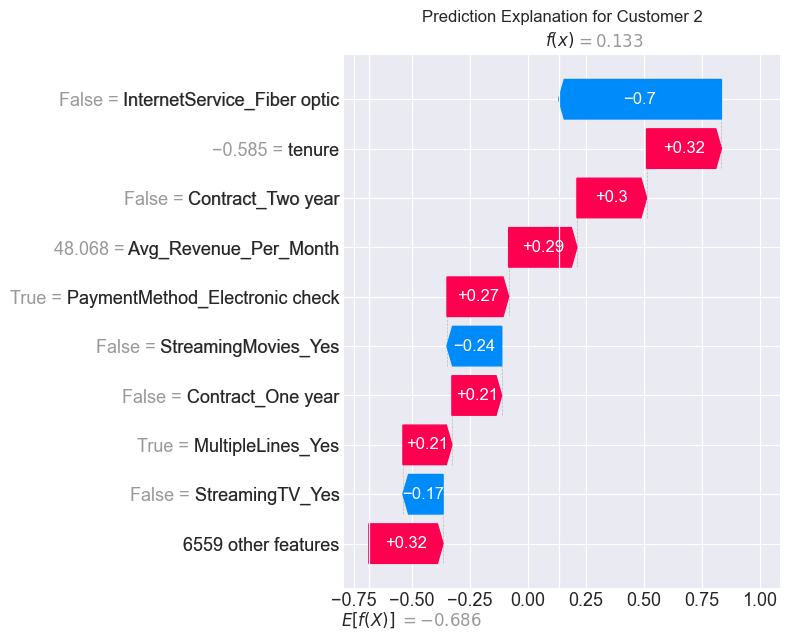

✅ Saved waterfall plot 3 to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_waterfall_customer_3.png


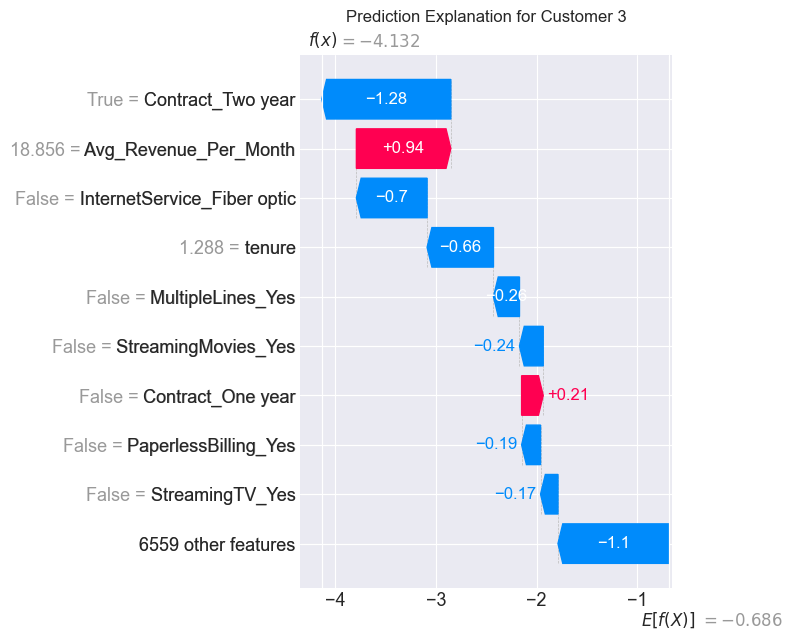

✅ Saved summary plot to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_summary_plot.png


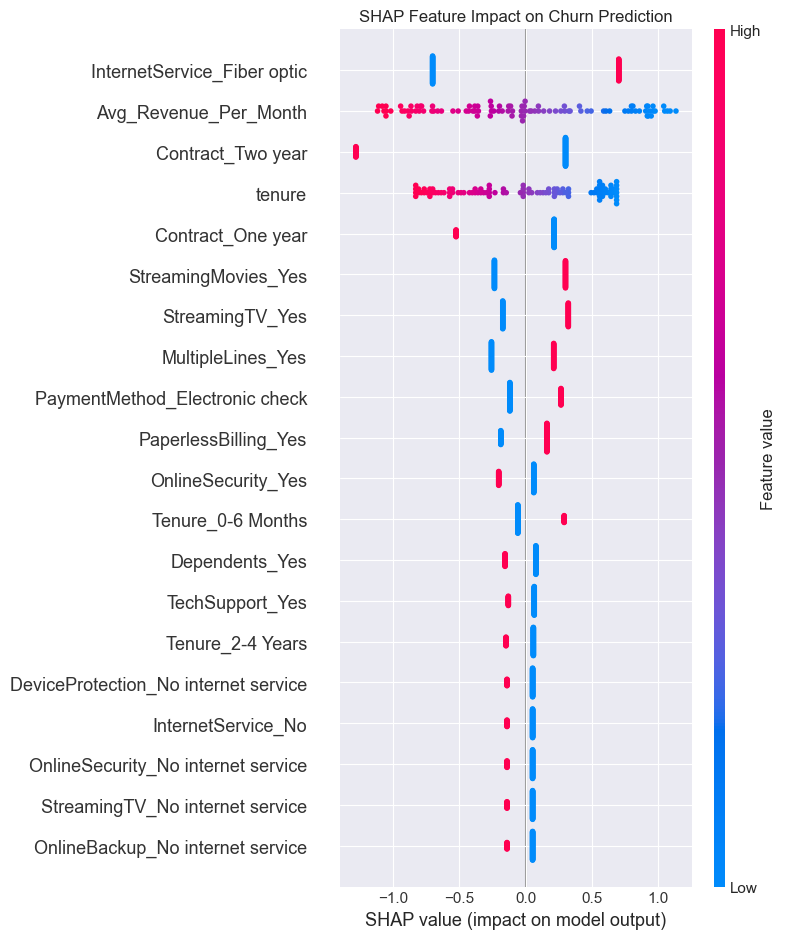

✅ Saved detailed feature importance plot to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_top20_features_detailed.png


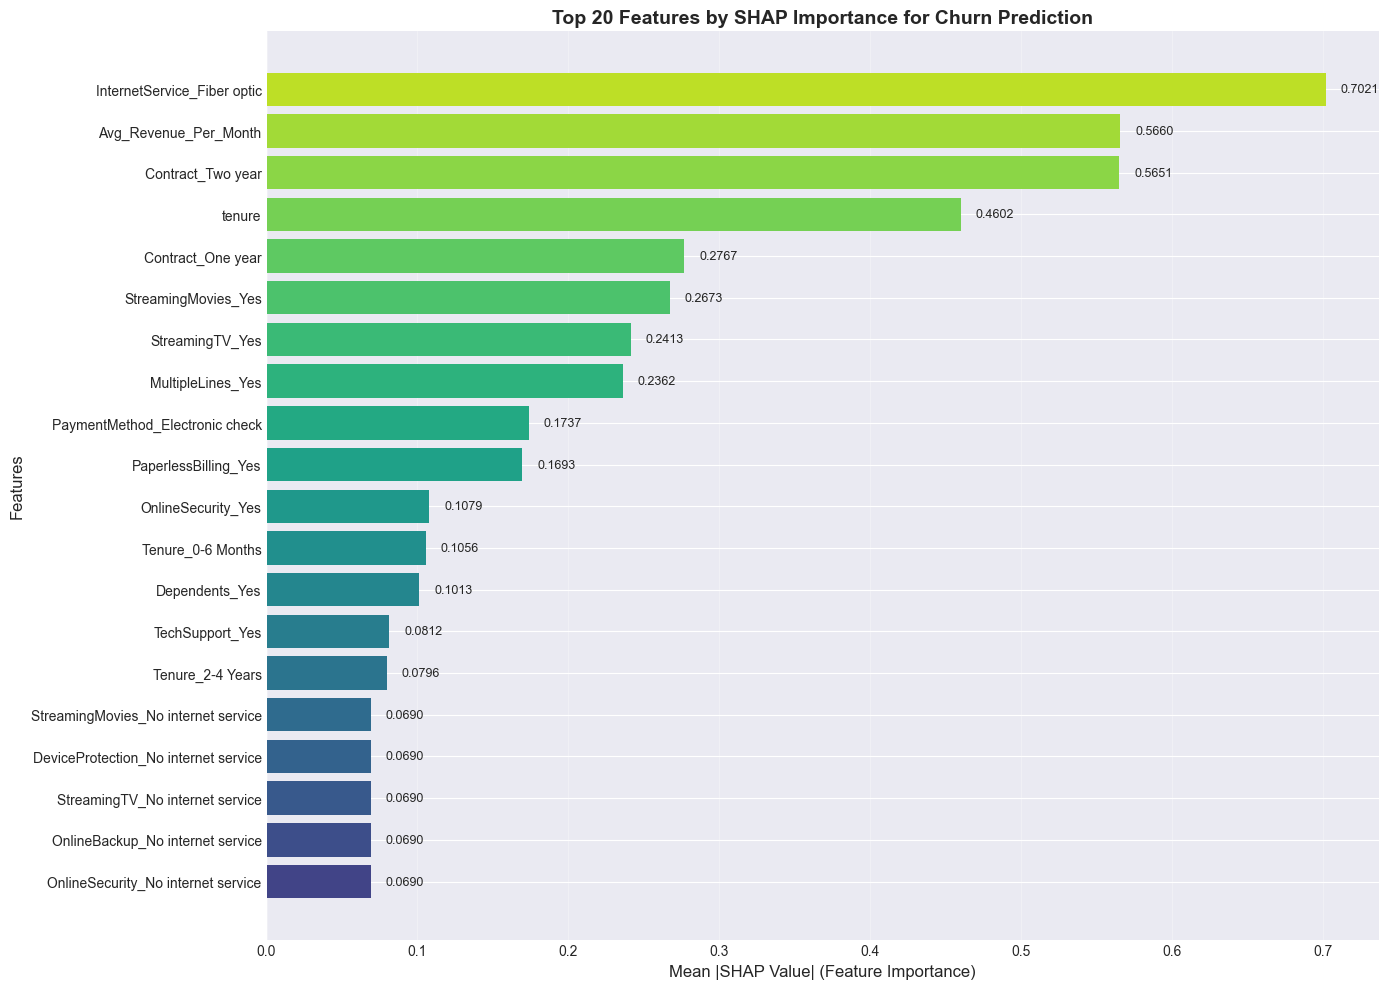

✅ Saved impact direction plot to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_impact_direction.png


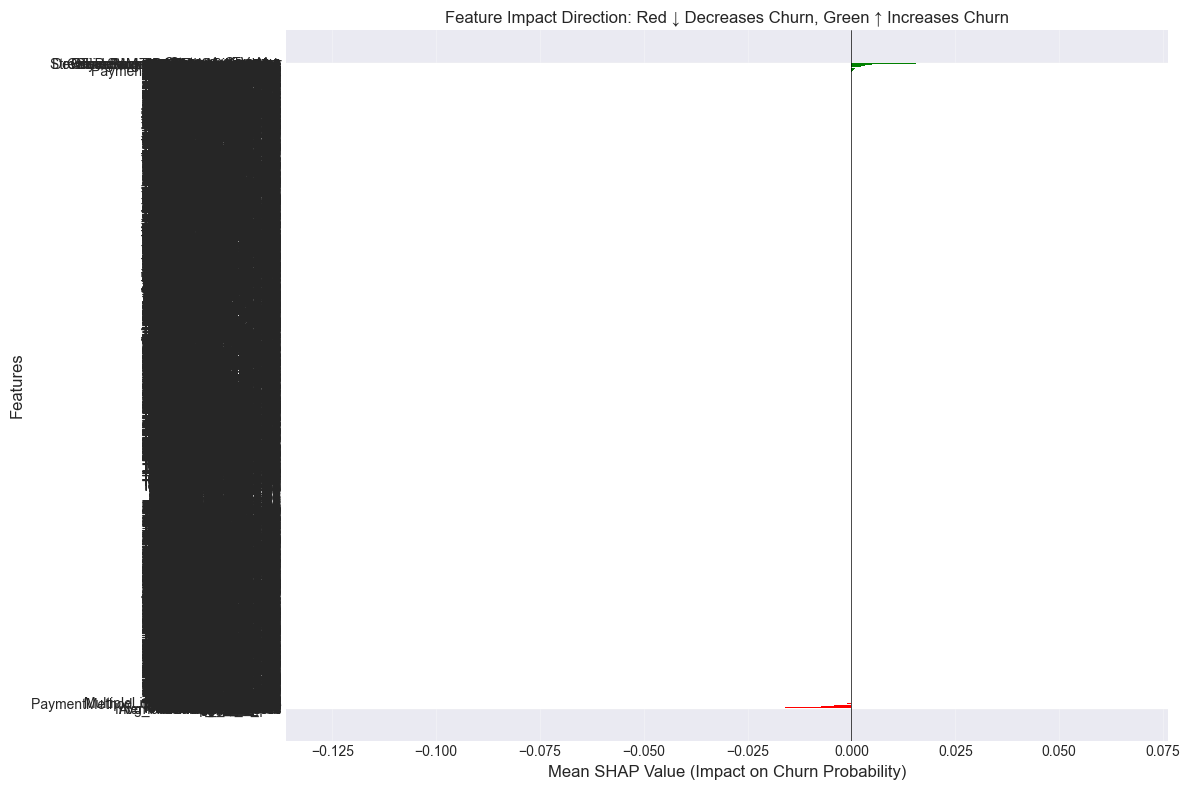


📈 Top 10 Most Important Features:
----------------------------------------
                       feature importance
          PaperlessBilling_Yes   0.169315
PaymentMethod_Electronic check   0.173717
             MultipleLines_Yes   0.236161
               StreamingTV_Yes   0.241303
           StreamingMovies_Yes   0.267301
             Contract_One year   0.276675
                        tenure   0.460175
             Contract_Two year   0.565121
         Avg_Revenue_Per_Month   0.565997
   InternetService_Fiber optic   0.702093

✅ Saved feature importance data to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures\shap_feature_importance.csv

✨ All plots have been saved to: C:/Users/pc/Documents/customer-churn-enterprise/reports/figures


In [24]:
import os
import warnings
warnings.filterwarnings('ignore')

# Create the directory if it doesn't exist
save_dir = r"C:/Users/pc/Documents/customer-churn-enterprise/reports/figures"
os.makedirs(save_dir, exist_ok=True)
print(f"📁 Saving plots to: {save_dir}")

print("\n🔮 Generating SHAP explanations (this may take a minute)...")

# Sample the data first
X_sample = X_test.sample(min(100, len(X_test)), random_state=42)

# Create LinearExplainer
explainer = shap.LinearExplainer(best_model, X_train, feature_perturbation="interventional")

# Get SHAP values
shap_values = explainer.shap_values(X_sample)

# Convert to numpy array and ensure correct type
shap_values = np.array(shap_values)
if len(shap_values.shape) == 3:  # If we have multiple dimensions (e.g., for multi-class)
    shap_values = shap_values[1]  # Take positive class for binary classification

# Method 1: Feature Importance Bar Chart
plt.figure(figsize=(12, 8))

# Create a custom summary plot
feature_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=True)

# Horizontal bar chart of feature importance
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('mean |SHAP value|')
plt.title('SHAP Feature Importance for Churn Prediction')
plt.tight_layout()

# Save the plot
bar_chart_path = os.path.join(save_dir, 'shap_feature_importance_bar.png')
plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved bar chart to: {bar_chart_path}")
plt.show()

# Method 2: Waterfall plots for individual predictions
print("\n📊 Individual prediction explanations:")
for i in range(min(3, len(X_sample))):  # Show first 3 predictions
    plt.figure(figsize=(10, 4))
    
    # Create explanation object
    exp = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[1],
        data=X_sample.iloc[i].values,
        feature_names=X_sample.columns.tolist()
    )
    
    shap.waterfall_plot(exp, show=False)
    plt.title(f'Prediction Explanation for Customer {i+1}')
    plt.tight_layout()
    
    # Save the plot
    waterfall_path = os.path.join(save_dir, f'shap_waterfall_customer_{i+1}.png')
    plt.savefig(waterfall_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved waterfall plot {i+1} to: {waterfall_path}")
    plt.show()

# Method 3: Summary plot with explicit casting
try:
    # Convert to proper format
    shap_values_clean = np.array(shap_values, dtype=np.float64)
    X_sample_clean = X_sample.values.astype(np.float64)
    
    # Get base value (handle both single value and array cases)
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[1]  # For binary classification
    else:
        base_val = explainer.expected_value
    
    # Create explanation object
    explanation = shap.Explanation(
        values=shap_values_clean,
        base_values=np.full(len(X_sample_clean), base_val),
        data=X_sample_clean,
        feature_names=X_sample.columns.tolist()
    )
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(explanation, show=False)
    plt.title("SHAP Feature Impact on Churn Prediction")
    plt.tight_layout()
    
    # Save the plot
    summary_path = os.path.join(save_dir, 'shap_summary_plot.png')
    plt.savefig(summary_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved summary plot to: {summary_path}")
    plt.show()
    
except Exception as e:
    print(f"Summary plot failed: {e}")
    print("Using alternative visualization...")
    
    # Alternative: Create a beeswarm-like plot manually
    plt.figure(figsize=(14, 10))
    
    # Get top 15 features for better visualization
    top_features = feature_importance.tail(15)['feature'].tolist()
    
    for i, col in enumerate(top_features):
        col_idx = X_sample.columns.get_loc(col)
        # Add jitter for better visualization
        y_jitter = i + np.random.normal(0, 0.05, len(shap_values))
        plt.scatter(
            shap_values[:, col_idx],
            y_jitter,
            alpha=0.5,
            s=15,
            c=shap_values[:, col_idx],
            cmap='RdBu_r',
            vmin=-np.abs(shap_values).max(),
            vmax=np.abs(shap_values).max()
        )
    
    plt.yticks(range(len(top_features)), top_features)
    plt.xlabel('SHAP Value (impact on model output)')
    plt.title('SHAP Values Distribution (Top 15 Features)')
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
    plt.colorbar(label='Feature value')
    plt.tight_layout()
    
    # Save the alternative plot
    alt_path = os.path.join(save_dir, 'shap_beeswarm_alternative.png')
    plt.savefig(alt_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved alternative beeswarm plot to: {alt_path}")
    plt.show()

# Method 4: Create a detailed feature importance plot with values
plt.figure(figsize=(14, 10))

# Get top 20 features
top_20_features = feature_importance.tail(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_20_features)))
bars = plt.barh(top_20_features['feature'], top_20_features['importance'], color=colors)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_20_features['importance'])):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Mean |SHAP Value| (Feature Importance)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 20 Features by SHAP Importance for Churn Prediction', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Save the detailed plot
detailed_path = os.path.join(save_dir, 'shap_top20_features_detailed.png')
plt.savefig(detailed_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved detailed feature importance plot to: {detailed_path}")
plt.show()

# Method 5: Feature impact direction plot
plt.figure(figsize=(12, 8))

# Calculate mean SHAP values for direction
feature_direction = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_shap': shap_values.mean(0)
}).sort_values('mean_shap', ascending=True)

# Color based on positive/negative impact
colors = ['red' if x < 0 else 'green' for x in feature_direction['mean_shap']]
bars = plt.barh(feature_direction['feature'], feature_direction['mean_shap'], color=colors)

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Mean SHAP Value (Impact on Churn Probability)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Impact Direction: Red ↓ Decreases Churn, Green ↑ Increases Churn', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Save the direction plot
direction_path = os.path.join(save_dir, 'shap_impact_direction.png')
plt.savefig(direction_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved impact direction plot to: {direction_path}")
plt.show()

# Print feature importance summary
print("\n📈 Top 10 Most Important Features:")
print("-" * 40)
print(feature_importance.tail(10).to_string(index=False))

# Save the feature importance data to CSV
importance_df = feature_importance.sort_values('importance', ascending=False)
csv_path = os.path.join(save_dir, 'shap_feature_importance.csv')
importance_df.to_csv(csv_path, index=False)
print(f"\n✅ Saved feature importance data to: {csv_path}")

print(f"\n✨ All plots have been saved to: {save_dir}")

#### 11. Save best model and create metadata

In [25]:
import joblib
import json
from datetime import datetime
import platform
import psutil

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name_clean = best_model_name.replace(" ", "_").lower()

# Save the model
model_filename = f'../models/{model_name_clean}_{timestamp}.pkl'
joblib.dump(best_model, model_filename)
print(f"✅ Model saved to: {model_filename}")

# Save the scaler if it exists
if 'scaler' in dir():
    scaler_filename = f'../models/scaler_{timestamp}.pkl'
    joblib.dump(scaler, scaler_filename)
    print(f"✅ Scaler saved to: {scaler_filename}")

# Get feature names
feature_names = X_train.columns.tolist()

# Calculate additional metrics
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, log_loss

y_pred_train = best_model.predict(X_train)
y_pred_train_proba = best_model.predict_proba(X_train)[:, 1]

# Comprehensive performance metrics
performance_metrics = {
    # Basic metrics
    'accuracy': float(results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['accuracy']),
    'precision': float(results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['precision']),
    'recall': float(results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['recall']),
    'f1_score': float(results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['f1']),
    'roc_auc': float(results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['roc_auc']),
    
    # Advanced metrics
    'mcc': float(matthews_corrcoef(y_test, results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['y_pred'])),
    'kappa': float(cohen_kappa_score(y_test, results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['y_pred'])),
    'log_loss': float(log_loss(y_test, results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['y_pred_proba'])),
    
    # Cross validation
    'cv_mean': float(results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['cv_mean']),
    'cv_std': float(results[best_model_name.split('Tuned ')[-1] if 'Tuned' in best_model_name else best_model_name]['cv_std']),
}

# Get feature importance
if hasattr(best_model, 'feature_importances_'):
    feature_importance_list = [
        {'feature': f, 'importance': float(imp)} 
        for f, imp in zip(feature_names, best_model.feature_importances_)
    ]
    # Sort by importance
    feature_importance_list = sorted(feature_importance_list, key=lambda x: x['importance'], reverse=True)
else:
    feature_importance_list = []

# Create comprehensive metadata
model_metadata = {
    'model_info': {
        'model_name': best_model_name,
        'model_type': type(best_model).__name__,
        'timestamp': timestamp,
        'datetime': datetime.now().isoformat(),
    },
    'performance': performance_metrics,
    'data_info': {
        'n_features': X_train.shape[1],
        'n_train_samples': int(X_train.shape[0]),
        'n_test_samples': int(X_test.shape[0]),
        'churn_rate_train': float(y_train.mean()),
        'churn_rate_test': float(y_test.mean()),
        'feature_names': feature_names,
    },
    'feature_importance': feature_importance_list[:20],  # Top 20 features
    'model_parameters': {k: str(v) for k, v in best_model.get_params().items()},  # Convert to string for JSON
    'environment': {
        'python_version': platform.python_version(),
        'platform': platform.platform(),
        'processor': platform.processor(),
        'ram_gb': round(psutil.virtual_memory().total / (1024**3), 2),
    },
    'files_generated': {
        'model': model_filename,
        'scaler': scaler_filename if 'scaler' in dir() else None,
        'shap_plots': [
            'shap_feature_importance_bar.png',
            'shap_summary_plot.png',
            'shap_top20_features_detailed.png',
            'shap_impact_direction.png',
            'shap_feature_importance.csv'
        ],
        'roc_curve': 'C:/Users/pc\Documents/customer-churn-enterprise/reports/figures/roc_curves.png',
        'confusion_matrices': 'C:/Users/pc\Documents/customer-churn-enterprise/reports/figures/confusion_matrices.png',
        'metrics_comparison': 'C:/Users/pc\Documents/customer-churn-enterprise/reports/figures/metrics_comparison.png',
    }
}

# Save metadata as JSON
metadata_filename = f'C:/Users/pc\Documents/customer-churn-enterprise/models/model_metadata_{timestamp}.json'
with open(metadata_filename, 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"✅ Model metadata saved to: {metadata_filename}")

# Also save a latest version (overwrite) for easy access
with open('C:/Users/pc\Documents/customer-churn-enterprise/models/model_metadata_latest.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("✅ Latest metadata saved to: C:/Users/pc\Documents/customer-churn-enterprise/models/model_metadata_latest.json")


✅ Model saved to: ../models/logistic_regression_20260309_160419.pkl
✅ Model metadata saved to: C:/Users/pc\Documents/customer-churn-enterprise/models/model_metadata_20260309_160419.json
✅ Latest metadata saved to: C:/Users/pc\Documents/customer-churn-enterprise/models/model_metadata_latest.json


#### 13. Generate HTML Report for Portfolio

In [28]:
# %% [markdown]
# ## 13. Generate HTML Report for Portfolio (Fixed)

# %%
# Create an HTML report for portfolio (without emojis)
html_filename = f'C:/Users/pc\Documents/customer-churn-enterprise/reports/model_report_{timestamp}.html'

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Customer Churn Prediction Model Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; }}
        h1 {{ color: #1E3A8A; }}
        h2 {{ color: #3B82F6; }}
        .metrics {{ display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; }}
        .metric-card {{ 
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 20px;
            border-radius: 10px;
            color: white;
            text-align: center;
        }}
        .feature-list {{ 
            background: #f0f2f6; 
            padding: 20px; 
            border-radius: 10px;
        }}
        table {{ width: 100%; border-collapse: collapse; }}
        th, td {{ padding: 12px; text-align: left; border-bottom: 1px solid #ddd; }}
        th {{ background-color: #3B82F6; color: white; }}
        .footer {{ margin-top: 40px; text-align: center; color: gray; }}
    </style>
</head>
<body>
    <h1>Customer Churn Prediction Model Report</h1>
    <p><strong>Date:</strong> {datetime.now().strftime('%B %d, %Y')}</p>
    <p><strong>Model:</strong> {best_model_name}</p>
    
    <h2>Performance Metrics</h2>
    <div class="metrics">
        <div class="metric-card">
            <h3>Accuracy</h3>
            <h1>{performance_metrics['accuracy']:.3f}</h1>
        </div>
        <div class="metric-card">
            <h3>Precision</h3>
            <h1>{performance_metrics['precision']:.3f}</h1>
        </div>
        <div class="metric-card">
            <h3>Recall</h3>
            <h1>{performance_metrics['recall']:.3f}</h1>
        </div>
        <div class="metric-card">
            <h3>F1-Score</h3>
            <h1>{performance_metrics['f1_score']:.3f}</h1>
        </div>
        <div class="metric-card">
            <h3>ROC-AUC</h3>
            <h1>{performance_metrics['roc_auc']:.3f}</h1>
        </div>
        <div class="metric-card">
            <h3>CV Score</h3>
            <h1>{performance_metrics['cv_mean']:.3f}</h1>
        </div>
    </div>
    
    <h2>Top 10 Feature Importance</h2>
    <div class="feature-list">
        <table>
            <tr>
                <th>Rank</th>
                <th>Feature</th>
                <th>Importance</th>
            </tr>
"""

for i, feat in enumerate(feature_importance_list[:10]):
    html_content += f"""
            <tr>
                <td>{i+1}</td>
                <td>{feat['feature']}</td>
                <td>{feat['importance']:.4f}</td>
            </tr>
"""

html_content += f"""
        </table>
    </div>
    
    <h2>Files Generated</h2>
    <ul>
        <li>Model: {model_filename}</li>
        <li>Metadata: {metadata_filename}</li>
        <li>SHAP Plots: reports/figures/ directory</li>
        <li>ROC Curves: reports/figures/roc_curves.png</li>
        <li>Confusion Matrices: reports/figures/confusion_matrices.png</li>
        <li>Metrics Comparison: reports/figures/metrics_comparison.png</li>
    </ul>
    
    <h2>Business Recommendations</h2>
    <ul>
        <li>Target retention campaigns at customers with less than 12 months tenure</li>
        <li>Offer incentives for annual and two-year contracts</li>
        <li>Promote automatic payment methods over electronic checks</li>
        <li>Bundle online security and tech support with internet service</li>
        <li>Focus retention efforts on fiber optic internet customers</li>
        <li>Create loyalty programs for customers reaching 12, 24, and 48 month milestones</li>
    </ul>
    
    <h2>Model Information</h2>
    <table>
        <tr>
            <th>Property</th>
            <th>Value</th>
        </tr>
        <tr>
            <td>Model Type</td>
            <td>{type(best_model).__name__}</td>
        </tr>
        <tr>
            <td>Number of Features</td>
            <td>{X_train.shape[1]}</td>
        </tr>
        <tr>
            <td>Training Samples</td>
            <td>{X_train.shape[0]}</td>
        </tr>
        <tr>
            <td>Test Samples</td>
            <td>{X_test.shape[0]}</td>
        </tr>
        <tr>
            <td>Python Version</td>
            <td>{platform.python_version()}</td>
        </tr>
    </table>
    
    <div class="footer">
        <hr>
        <p>Generated by Customer Churn Prediction Pipeline | Codec Technologies Internship Project</p>
        <p>{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    </div>
</body>
</html>
"""

# Write with UTF-8 encoding explicitly
with open(html_filename, 'w', encoding='utf-8') as f:
    f.write(html_content)
print(f"✅ HTML report saved to: {html_filename}")

✅ HTML report saved to: C:/Users/pc\Documents/customer-churn-enterprise/reports/model_report_20260309_160419.html
